In [13]:
import os
# Create figures folder if it doesn't exist
os.makedirs('figures', exist_ok=True)
FIGURES_DIR = 'figures'

# Part 2: Monte Carlo Prediction

## Q2.1, Q2.2, Q2.3: MC Prediction and Convergence Analysis

This notebook covers:
- **Q2.1**: MC Prediction on 2×3 grid (First-visit vs Every-visit)
- **Q2.2**: Convergence analysis and speed comparison
- **Q2.3**: Empirical MC from given trajectories

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld import GridWorld
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Helper Functions: MC Prediction Methods

In [15]:
def create_2x3_grid():
    """Create 2×3 gridworld with custom terminal rewards."""
    def reward_fn(state, action, next_state):
        if next_state == 0:
            return -1.0
        elif next_state == 1:
            return 1.0
        elif next_state == 2:
            return 0.0
        else:
            return 0.0
    
    env = GridWorld(N=2, ncols=3, terminal_states={0, 1, 2}, reward_fn=reward_fn)
    policy = np.zeros((env.n_states, env.n_actions))
    policy[:, 0] = 1.0  # Always UP
    env.set_policy(policy)
    return env

def first_visit_mc(env, num_episodes=1000):
    """First-visit Monte Carlo prediction."""
    V = np.zeros(env.n_states)
    returns_sum = np.zeros(env.n_states)
    visit_count = np.zeros(env.n_states)
    visit_history = []
    
    for _ in range(num_episodes):
        episode = env.generate_episode(start_state=None, max_steps=100)
        G = 0
        visited_in_episode = set()
        
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            
            if state not in visited_in_episode:
                visited_in_episode.add(state)
                returns_sum[state] += G
                visit_count[state] += 1
        
        V_snapshot = np.where(visit_count > 0, returns_sum / visit_count, 0.0)
        visit_history.append(V_snapshot.copy())
    
    V = np.where(visit_count > 0, returns_sum / visit_count, 0.0)
    return V, np.array(visit_history)

def every_visit_mc(env, num_episodes=1000):
    """Every-visit Monte Carlo prediction."""
    V = np.zeros(env.n_states)
    returns_sum = np.zeros(env.n_states)
    visit_count = np.zeros(env.n_states)
    visit_history = []
    
    for _ in range(num_episodes):
        episode = env.generate_episode(start_state=None, max_steps=100)
        G = 0
        
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            returns_sum[state] += G
            visit_count[state] += 1
        
        V_snapshot = np.where(visit_count > 0, returns_sum / visit_count, 0.0)
        visit_history.append(V_snapshot.copy())
    
    V = np.where(visit_count > 0, returns_sum / visit_count, 0.0)
    return V, np.array(visit_history)

---
# Q2.1: MC Prediction on 2×3 Grid

**Environment:**
- States: S0(terminal, r=-1), S1(terminal, r=+1), S2(terminal, r=0), S3, S4, S5
- Policy: Always UP
- Expected values: V(S3)=-1, V(S4)=+1, V(S5)=0

In [16]:
env = create_2x3_grid()
print(f"Environment: 2×3 Grid")
print(f"States: S0(terminal), S1(terminal), S2(terminal), S3, S4, S5")
print(f"Policy: Always UP (action 0)")
print(f"Terminal rewards: S0→-1, S1→+1, S2→0")
print(f"\nExpected convergence values:")
print(f"  V(S3) = -1 (reaches S0)")
print(f"  V(S4) = +1 (reaches S1)")
print(f"  V(S5) =  0 (reaches S2)")

Environment: 2×3 Grid
States: S0(terminal), S1(terminal), S2(terminal), S3, S4, S5
Policy: Always UP (action 0)
Terminal rewards: S0→-1, S1→+1, S2→0

Expected convergence values:
  V(S3) = -1 (reaches S0)
  V(S4) = +1 (reaches S1)
  V(S5) =  0 (reaches S2)


In [17]:
# Run MC prediction
num_episodes = 5000
print(f"\nRunning First-Visit MC with {num_episodes} episodes...")
V_fv, fv_history = first_visit_mc(env, num_episodes=num_episodes)

print(f"Running Every-Visit MC with {num_episodes} episodes...")
V_ev, ev_history = every_visit_mc(env, num_episodes=num_episodes)

print(f"\nFirst-Visit MC Value Estimates:")
for s in range(env.n_states):
    print(f"  V(S{s}) = {V_fv[s]:7.4f}")

print(f"\nEvery-Visit MC Value Estimates:")
for s in range(env.n_states):
    print(f"  V(S{s}) = {V_ev[s]:7.4f}")

print(f"\nExpected true values:")
print(f"  V(S0)=0  V(S1)=0  V(S2)=0")
print(f"  V(S3)=-1 V(S4)=+1 V(S5)=0")


Running First-Visit MC with 5000 episodes...
Running Every-Visit MC with 5000 episodes...

First-Visit MC Value Estimates:
  V(S0) =  0.0000
  V(S1) =  0.0000
  V(S2) =  0.0000
  V(S3) = -1.0000
  V(S4) =  1.0000
  V(S5) =  0.0000

Every-Visit MC Value Estimates:
  V(S0) =  0.0000
  V(S1) =  0.0000
  V(S2) =  0.0000
  V(S3) = -1.0000
  V(S4) =  1.0000
  V(S5) =  0.0000

Expected true values:
  V(S0)=0  V(S1)=0  V(S2)=0
  V(S3)=-1 V(S4)=+1 V(S5)=0


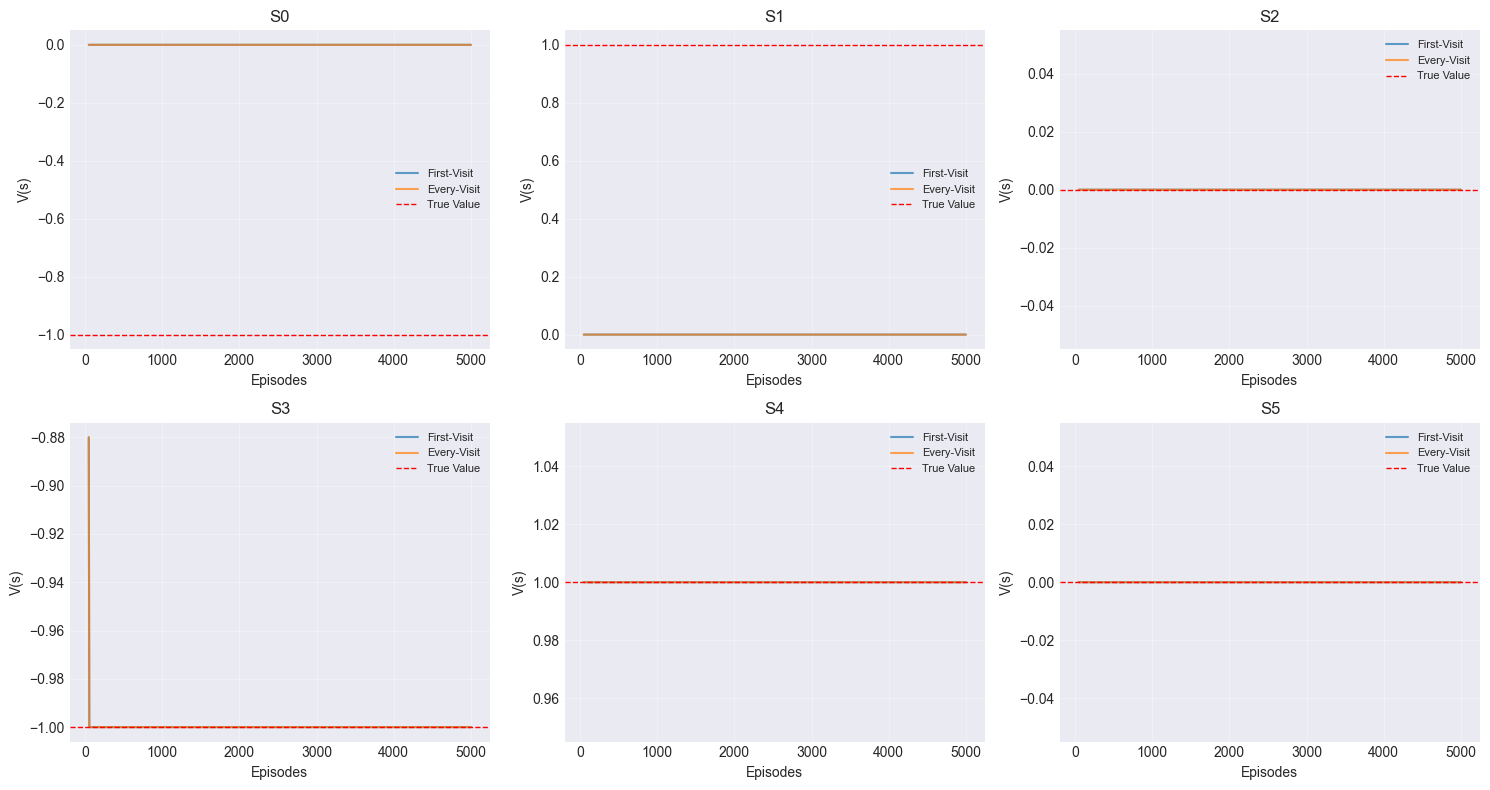


✓ Q2.1 Deliverables:
  1. Estimated value table: V(s) for each state
  2. Learning curves: First-Visit vs Every-Visit


In [18]:
# Learning curves
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
true_values = [-1, 1, 0, -1, 1, 0]
window = 50

for s in range(6):
    ax = axes[s // 3, s % 3]
    
    fv_smooth = np.convolve(fv_history[:, s], np.ones(window)/window, mode='valid')
    ev_smooth = np.convolve(ev_history[:, s], np.ones(window)/window, mode='valid')
    episodes = np.arange(len(fv_smooth)) + window
    
    ax.plot(episodes, fv_smooth, label='First-Visit', alpha=0.7, linewidth=1.5)
    ax.plot(episodes, ev_smooth, label='Every-Visit', alpha=0.7, linewidth=1.5)
    ax.axhline(y=true_values[s], color='r', linestyle='--', label='True Value', linewidth=1)
    ax.set_xlabel('Episodes')
    ax.set_ylabel('V(s)')
    ax.set_title(f'S{s}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'q2_1_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Q2.1 Deliverables:")
print("  1. Estimated value table: V(s) for each state")
print("  2. Learning curves: First-Visit vs Every-Visit")

---
# Q2.2: MC Convergence Analysis

**Define convergence:** max_s |V_{k+1}(s) - V_k(s)| < 0.01

In [19]:
def first_visit_mc_converge(env, convergence_threshold=0.01, max_episodes=10000):
    """First-Visit MC with convergence tracking."""
    V = np.zeros(env.n_states)
    returns_sum = np.zeros(env.n_states)
    visit_count = np.zeros(env.n_states)
    max_changes = []
    converge_episode = -1
    
    for episode_num in range(max_episodes):
        episode = env.generate_episode(start_state=None, max_steps=100)
        V_old = V.copy()
        G = 0
        visited_in_episode = set()
        
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            if state not in visited_in_episode:
                visited_in_episode.add(state)
                returns_sum[state] += G
                visit_count[state] += 1
        
        V = np.where(visit_count > 0, returns_sum / visit_count, 0.0)
        max_change = np.max(np.abs(V - V_old))
        max_changes.append(max_change)
        
        if converge_episode == -1 and max_change < convergence_threshold:
            converge_episode = episode_num + 1
    
    return V, np.array(max_changes), converge_episode

def every_visit_mc_converge(env, convergence_threshold=0.01, max_episodes=10000):
    """Every-Visit MC with convergence tracking."""
    V = np.zeros(env.n_states)
    returns_sum = np.zeros(env.n_states)
    visit_count = np.zeros(env.n_states)
    max_changes = []
    converge_episode = -1
    
    for episode_num in range(max_episodes):
        episode = env.generate_episode(start_state=None, max_steps=100)
        V_old = V.copy()
        G = 0
        
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            returns_sum[state] += G
            visit_count[state] += 1
        
        V = np.where(visit_count > 0, returns_sum / visit_count, 0.0)
        max_change = np.max(np.abs(V - V_old))
        max_changes.append(max_change)
        
        if converge_episode == -1 and max_change < convergence_threshold:
            converge_episode = episode_num + 1
    
    return V, np.array(max_changes), converge_episode

In [20]:
# Run convergence analysis
convergence_threshold = 0.01
max_episodes = 5000

print(f"Convergence threshold: {convergence_threshold}\n")
print(f"Running First-Visit MC ({max_episodes} episodes max)...")
V_fv, changes_fv, conv_ep_fv = first_visit_mc_converge(
    env, convergence_threshold=convergence_threshold, max_episodes=max_episodes
)

print(f"Running Every-Visit MC ({max_episodes} episodes max)...")
V_ev, changes_ev, conv_ep_ev = every_visit_mc_converge(
    env, convergence_threshold=convergence_threshold, max_episodes=max_episodes
)

print(f"\nFirst-Visit MC:")
print(f"  Converged at episode: {conv_ep_fv}")

print(f"\nEvery-Visit MC:")
print(f"  Converged at episode: {conv_ep_ev}")

if conv_ep_fv > 0 and conv_ep_ev > 0:
    faster = "First-Visit" if conv_ep_fv < conv_ep_ev else "Every-Visit"
    speedup = max(conv_ep_fv, conv_ep_ev) / min(conv_ep_fv, conv_ep_ev)
    print(f"\n{faster} converges ~{speedup:.2f}x faster")

Convergence threshold: 0.01

Running First-Visit MC (5000 episodes max)...
Running Every-Visit MC (5000 episodes max)...

First-Visit MC:
  Converged at episode: 2

Every-Visit MC:
  Converged at episode: 3

First-Visit converges ~1.50x faster


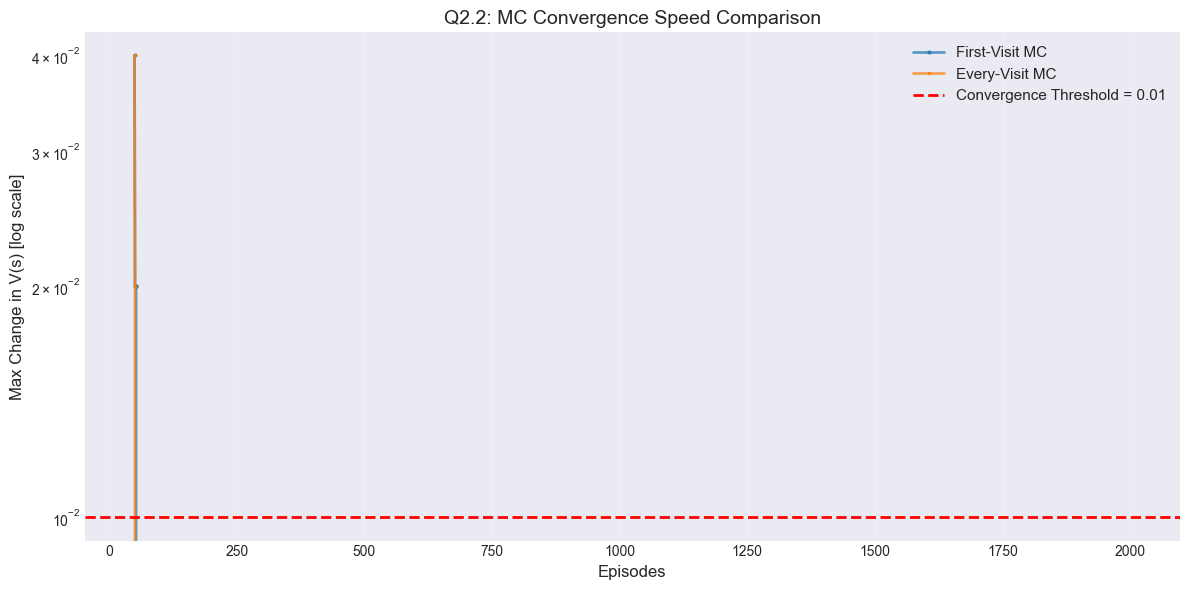


✓ Q2.2 Deliverables:
  1. Convergence plot
  2. First-Visit convergence: 2 episodes
  3. Every-Visit convergence: 3 episodes


In [21]:
# Plot convergence comparison
fig, ax = plt.subplots(figsize=(12, 6))

max_eps_plot = min(2000, max_episodes)
window = 50

changes_fv_smooth = np.convolve(changes_fv[:max_eps_plot], np.ones(window)/window, mode='valid')
changes_ev_smooth = np.convolve(changes_ev[:max_eps_plot], np.ones(window)/window, mode='valid')
episodes = np.arange(len(changes_fv_smooth)) + window

ax.semilogy(episodes, changes_fv_smooth, marker='o', markersize=2, 
            label='First-Visit MC', linewidth=2, alpha=0.7)
ax.semilogy(episodes, changes_ev_smooth, marker='s', markersize=2, 
            label='Every-Visit MC', linewidth=2, alpha=0.7)
ax.axhline(y=convergence_threshold, color='r', linestyle='--', 
           linewidth=2, label=f'Convergence Threshold = {convergence_threshold}')

ax.set_xlabel('Episodes', fontsize=12)
ax.set_ylabel('Max Change in V(s) [log scale]', fontsize=12)
ax.set_title('Q2.2: MC Convergence Speed Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'q2_2_convergence_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Q2.2 Deliverables:")
print(f"  1. Convergence plot")
print(f"  2. First-Visit convergence: {conv_ep_fv} episodes")
print(f"  3. Every-Visit convergence: {conv_ep_ev} episodes")

---
# Q2.3: Empirical MC from Trajectories

**Given Episodes (γ=1):**
- Episode 1: s1, a1, +3, s1, a2, +2, s2, a2, -4, s1, a2, +4, s2, a1, -3, [terminal]
- Episode 2: s2, a1, -2, s1, a2, +3, s2, a2, -3, [terminal]
- Episode 3: s1, a1, +1, s1, a2, +4, s1, a2, +1, s2, a1, -1, [terminal]

**Tasks:**
- First-visit V(s)
- Every-visit V(s)
- First-visit Q(s,a)
- P(s'|s,a), R(s,a)
- π(a|s)

In [22]:
# Parse episodes
episodes = [
    [('s1', 'a1', 3), ('s1', 'a2', 2), ('s2', 'a2', -4), ('s1', 'a2', 4), ('s2', 'a1', -3)],
    [('s2', 'a1', -2), ('s1', 'a2', 3), ('s2', 'a2', -3)],
    [('s1', 'a1', 1), ('s1', 'a2', 4), ('s1', 'a2', 1), ('s2', 'a1', -1)],
]

print("Episodes:")
for i, ep in enumerate(episodes, 1):
    traj = " → ".join([f"{s}({a},{r:+d})" for s, a, r in ep])
    print(f"Episode {i}: {traj} → [terminal]")

Episodes:
Episode 1: s1(a1,+3) → s1(a2,+2) → s2(a2,-4) → s1(a2,+4) → s2(a1,-3) → [terminal]
Episode 2: s2(a1,-2) → s1(a2,+3) → s2(a2,-3) → [terminal]
Episode 3: s1(a1,+1) → s1(a2,+4) → s1(a2,+1) → s2(a1,-1) → [terminal]


In [23]:
# a. First-visit V(s)
def first_visit_v(episodes):
    returns = defaultdict(list)
    for episode in episodes:
        G = 0
        visited_states = set()
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            if state not in visited_states:
                visited_states.add(state)
                returns[state].append(G)
    V = {s: np.mean(rets) for s, rets in returns.items()}
    return V, returns

# b. Every-visit V(s)
def every_visit_v(episodes):
    returns = defaultdict(list)
    for episode in episodes:
        G = 0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            returns[state].append(G)
    V = {s: np.mean(rets) for s, rets in returns.items()}
    return V, returns

# c. First-visit Q(s,a)
def first_visit_q(episodes):
    returns = defaultdict(list)
    for episode in episodes:
        G = 0
        visited_sa = set()
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + G
            sa_pair = (state, action)
            if sa_pair not in visited_sa:
                visited_sa.add(sa_pair)
                returns[sa_pair].append(G)
    Q = {sa: np.mean(rets) for sa, rets in returns.items()}
    return Q, returns

# d. Transition probs and rewards
def transition_probabilities(episodes):
    transitions = defaultdict(lambda: defaultdict(int))
    rewards = defaultdict(list)
    for episode in episodes:
        for i in range(len(episode)):
            state, action, reward = episode[i]
            next_state = episode[i + 1][0] if i + 1 < len(episode) else "terminal"
            sa = (state, action)
            transitions[sa][next_state] += 1
            rewards[sa].append(reward)
    P = {sa: {s: c/sum(transitions[sa].values()) for s, c in transitions[sa].items()} 
         for sa in transitions}
    R = {sa: np.mean(rewards[sa]) for sa in rewards}
    return P, R

# e. Policy estimation
def estimate_policy(Q):
    policy = {}
    states = set(s for s, a in Q.keys())
    for s in states:
        actions = {a: Q.get((s, a), 0) for a in ['a1', 'a2']}
        greedy_action = max(actions, key=actions.get)
        policy[s] = {'a1': 0.0, 'a2': 0.0}
        policy[s][greedy_action] = 1.0
    return policy

# Compute all values
V_fv, ret_fv = first_visit_v(episodes)
V_ev, ret_ev = every_visit_v(episodes)
Q_fv, ret_q = first_visit_q(episodes)
P, R = transition_probabilities(episodes)
policy = estimate_policy(Q_fv)

print("\n" + "="*70)
print("a. FIRST-VISIT V(s)")
print("="*70)
for s in sorted(V_fv.keys()):
    print(f"  V({s}) = {V_fv[s]:.2f}")

print("\n" + "="*70)
print("b. EVERY-VISIT V(s)")
print("="*70)
for s in sorted(V_ev.keys()):
    print(f"  V({s}) = {V_ev[s]:.2f}")

print("\n" + "="*70)
print("c. FIRST-VISIT Q(s,a)")
print("="*70)
for sa in sorted(ret_q.keys()):
    s, a = sa
    print(f"  Q({s},{a}) = {Q_fv[sa]:.2f}")


a. FIRST-VISIT V(s)
  V(s1) = 0.33
  V(s2) = -2.33

b. EVERY-VISIT V(s)
  V(s1) = 1.57
  V(s2) = -2.40

c. FIRST-VISIT Q(s,a)
  Q(s1,a1) = 3.50
  Q(s1,a2) = 0.33
  Q(s2,a1) = -2.00
  Q(s2,a2) = -3.00


In [24]:
print("\n" + "="*70)
print("d. TRANSITION PROBABILITIES P(s'|s,a) AND REWARDS R(s,a)")
print("="*70)
for sa in sorted(P.keys()):
    s, a = sa
    next_dist = P[sa]
    dist_str = ", ".join([f"{ns}:{p:.2f}" for ns, p in next_dist.items()])
    reward = R[sa]
    print(f"  From {s} with {a}: {{{dist_str}}} | R({s},{a}) = {reward:.2f}")

print("\n" + "="*70)
print("e. ESTIMATED POLICY π(a|s)")
print("="*70)
for s in sorted(policy.keys()):
    p_a1 = policy[s]['a1']
    p_a2 = policy[s]['a2']
    greedy_action = 'a1' if p_a1 > p_a2 else 'a2'
    print(f"  π({s}) = {{a1:{p_a1:.1f}, a2:{p_a2:.1f}}} | Greedy: {greedy_action}")

print("\n✓ Q2.3 Deliverables: All values computed and displayed above.")


d. TRANSITION PROBABILITIES P(s'|s,a) AND REWARDS R(s,a)
  From s1 with a1: {s1:1.00} | R(s1,a1) = 2.00
  From s1 with a2: {s2:0.80, s1:0.20} | R(s1,a2) = 2.80
  From s2 with a1: {terminal:0.67, s1:0.33} | R(s2,a1) = -2.00
  From s2 with a2: {s1:0.50, terminal:0.50} | R(s2,a2) = -3.50

e. ESTIMATED POLICY π(a|s)
  π(s1) = {a1:1.0, a2:0.0} | Greedy: a1
  π(s2) = {a1:1.0, a2:0.0} | Greedy: a1

✓ Q2.3 Deliverables: All values computed and displayed above.
